# Task 2: Exploratory Data Analysis (EDA) & Business Intelligence
This notebook analyzes the cleaned sales dataset using descriptive statistics, univariate analysis, multivariate analysis, and business-focused visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

In [2]:
file_path = Path('../data/processed/cleaned_sales_dataset.csv')
df = pd.read_csv(file_path, parse_dates=['Order_Date'])
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


## 1. Dataset Overview and Data Quality Check

In [3]:
print('Dataset Shape:', df.shape)
display(df.info())
print('\nMissing Values:')
display(df.isnull().sum())

Dataset Shape: (1000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   str           
 1   Order_Date     1000 non-null   datetime64[us]
 2   Customer_ID    1000 non-null   str           
 3   Customer_Name  1000 non-null   str           
 4   Age            1000 non-null   float64       
 5   Gender         1000 non-null   str           
 6   City           1000 non-null   str           
 7   Product        1000 non-null   str           
 8   Category       1000 non-null   str           
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(7)
memory usage: 93.9 KB


None


Missing Values:


Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64

## 2. Descriptive Statistics

In [4]:
df[['Age', 'Quantity', 'Unit_Price', 'Total_Sales']].describe()

,Age,Quantity,Unit_Price,Total_Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650
std,13.683626,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,53.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


## 3. Univariate Analysis

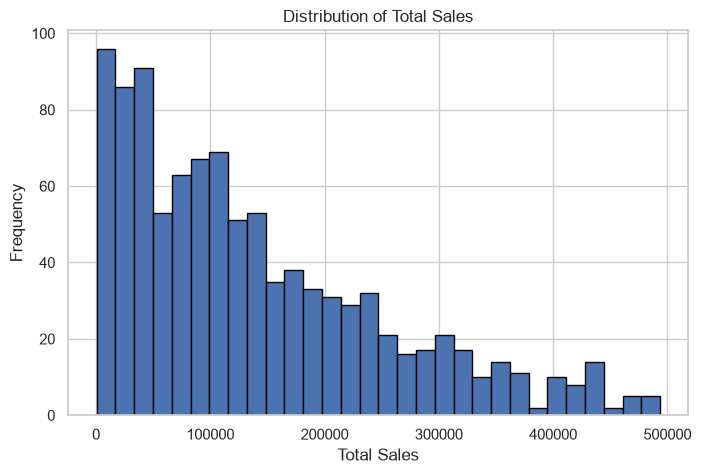

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df['Total_Sales'], bins=30, edgecolor='black')
plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

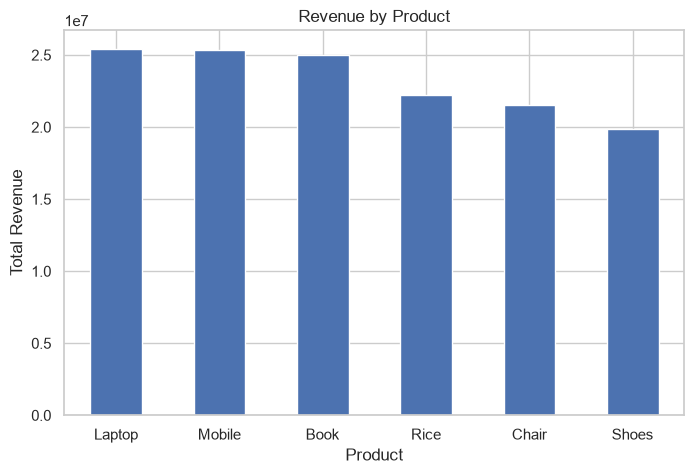

In [6]:
product_revenue = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
product_revenue.plot(kind='bar', figsize=(8, 5))
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

## 4. Multivariate Analysis and Correlation

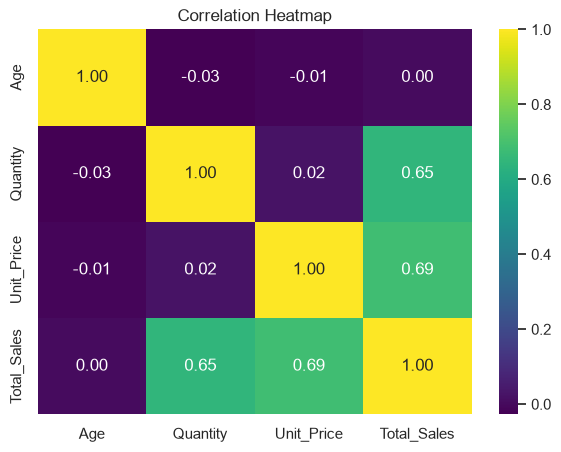

In [7]:
numeric_cols = ['Age', 'Quantity', 'Unit_Price', 'Total_Sales']
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='viridis')
plt.title('Correlation Heatmap')
plt.show()

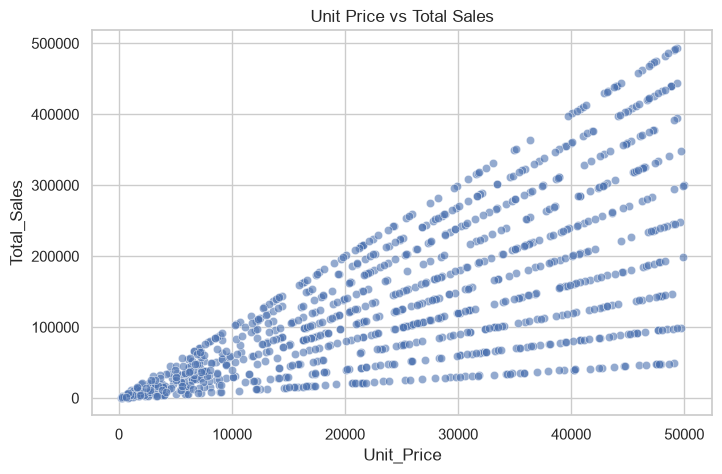

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Unit_Price', y='Total_Sales', alpha=0.6)
plt.title('Unit Price vs Total Sales')
plt.show()

## 5. Monthly Trend Analysis

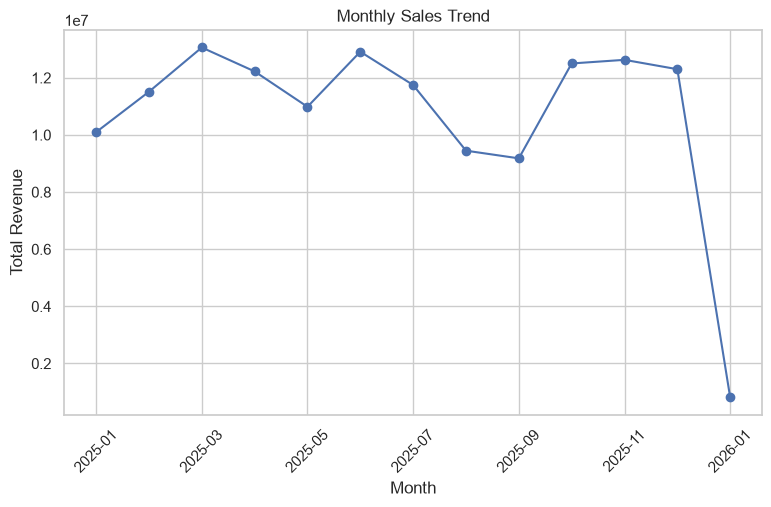

In [9]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(kind='line', marker='o', figsize=(9, 5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## 6. Key Business Insights

In [10]:
kpis = {
    'Total Revenue': df['Total_Sales'].sum(),
    'Total Orders': len(df),
    'Unique Customers': df['Customer_ID'].nunique(),
    'Total Quantity Sold': df['Quantity'].sum(),
    'Average Order Value': df['Total_Sales'].mean()
}
pd.Series(kpis)

Total Revenue          1.393994e+08
Total Orders           1.000000e+03
Unique Customers       9.470000e+02
Total Quantity Sold    5.435000e+03
Average Order Value    1.393994e+05
dtype: float64